# Tutorial 2: Probability Distributions

In this tutorial, you will use **simulation in Python** to build intuition about probability distributions commonly used in health and engineering.

**What you'll practice (learning objectives):**
1. Simulate data from discrete (Poisson) and continuous (Normal) distributions
2. Visualize empirical distributions and compare them to theoretical distributions
3. Calculate probabilities using scipy.stats distribution methods

## Prepare Environment and Notebook

In [4]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Create random number generator with seed 2026 for reproducibility
# Using the same seed means everyone gets the same "random" data
rng = np.random.default_rng(2026)

# Step 1: Poisson Distribution (Discrete) - Hospital Admissions per Day

## Context: What is a Poisson Distribution?

We often need to model **count data** — things we can count but not measure continuously:
- Number of hospital admissions per day
- Number of patient falls per week  
- Number of emergency calls per hour

The **Poisson distribution** is perfect for modeling these types of count data when:
- Events happen independently (one event doesn't affect another)
- Events happen at a constant average rate
- We're counting events in a fixed time period

### Poisson Distribution Parameter

The Poisson distribution has **one parameter**:
- **λ (lambda)**: The average rate (mean number of events in the time period)

**Key Property:** For Poisson distributions, **mean = variance = λ**

## Scenario: Remote Medical Clinic

**Context:** A remote medical clinic refers patients to a hospital for admission.

**Given:** On average, there are **λ = 2.6 admissions per day**.

**Questions we want to answer:**
1. What does the distribution of daily admissions look like?
2. How do simulated admissions compare to the theoretical distribution?
3. What's the probability of having 3 or fewer admissions on a given day?

## Step 1.1: Set Up Simulation Parameters

First, let's define the parameters for our simulation.

In [2]:
# Number of days to simulate
N = 10000  # We'll simulate 10,000 days to get good estimates

# Poisson parameter: average admissions per day
lam = 2.6  # lambda (λ) = 2.6 admissions/day

## Step 1.2: Simulate Poisson Data

Now we'll use `scipy.stats` to generate random data from a Poisson distribution.

In [3]:
# Generate random data from Poisson(λ=2.6)
# This simulates the number of admissions for each of the 10,000 days
admissions = stats.poisson.rvs(size=N, mu=lam, random_state=rng)

print(f"Total days simulated: {N}")
print(f"Total admissions across all days: {admissions.sum()}")

Total days simulated: 10000
Total admissions across all days: 25979


**What does `stats.poisson.rvs()` do?**
- `rvs` stands for "random variates" (random samples)
- `size=N` means generate N random values
- `mu=lam` sets the mean (λ) of the Poisson distribution
- `random_state=rng` uses our random number generator for reproducibility

## Step 1.3: Look at the Simulated Data

Let's examine the first 20 days to see what the data looks like.

In [4]:
print("Number of admissions for the first 20 days:")
print(admissions[:20])

Number of admissions for the first 20 days:
[2 4 6 3 2 1 2 3 6 3 2 2 4 4 0 3 3 3 5 1]


Notice: These are whole numbers (counts), not decimals!

## Step 1.4: Visualize the Distribution

Now we'll create a visualization comparing our simulated data (empirical) to the theoretical Poisson distribution.

**What is PMF?**
- PMF = Probability Mass Function (for discrete distributions)
- It tells us: P(X = k) for each possible value k
- Example: P(X = 2) means "probability of exactly 2 admissions"

**What is `stats.poisson.pmf()`?**
- `pmf` = probability mass function
- It calculates P(X = k) for the theoretical Poisson(λ=2.6) distribution
- This is the formula: P(X = k) = (e^(-λ) × λ^k) / k!

### TASK 1: Calculate Empirical and Theoretical PMF

**Part A - Empirical PMF:**
- Calculate the empirical probabilities by dividing the counts by N (the total number of observations)

**Part B - Theoretical PMF:**
- Use `stats.poisson.pmf()` to calculate the theoretical probability for each value in the range `k`

**Instructions:**
- For Part A: Calculate `empirical_pmf` using the `counts` and `N` variables
- For Part B: Calculate `theoretical_pmf` using `stats.poisson.pmf()` with the appropriate parameters

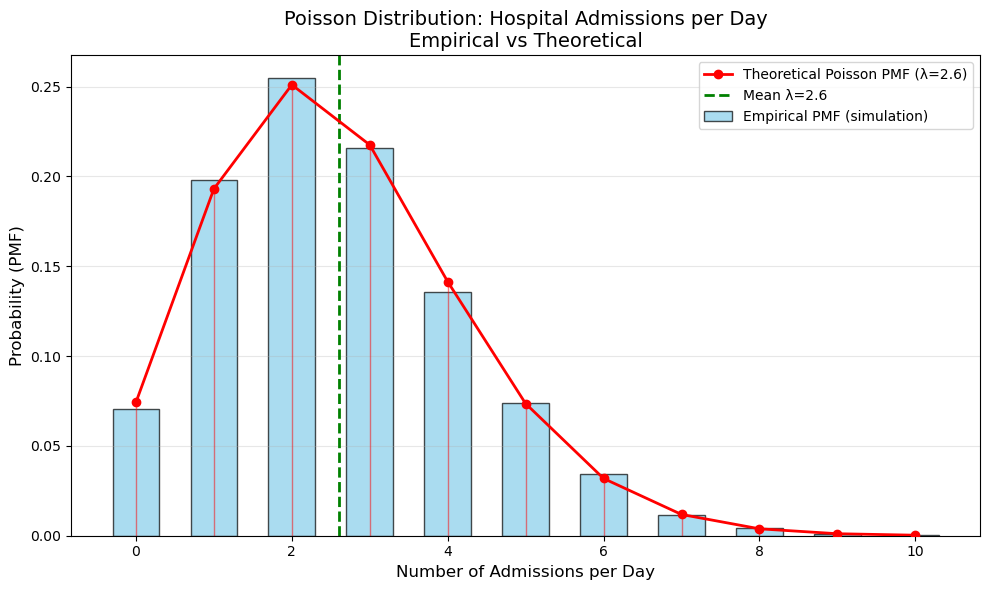

In [5]:
# Count how many times each value appears in our data
values, counts = np.unique(admissions, return_counts=True)

# --- YOUR CODE HERE ---
empirical_pmf = counts / N
# --- END YOUR CODE ---

# Determine range of values to plot (0 to 99.9th percentile)
k_max = int(max(admissions.max(), np.ceil(stats.poisson.ppf(0.999, lam))))
k = np.arange(0, k_max + 1)  # All possible values from 0 to k_max

# --- YOUR CODE HERE ---
theoretical_pmf = stats.poisson.pmf(k, mu=lam)
# --- END YOUR CODE ---

# Create figure
plt.figure(figsize=(10, 6))

# --- Plot Empirical PMF (from our simulation) ---
plt.bar(values, empirical_pmf, width=0.6, alpha=0.7,
        label="Empirical PMF (simulation)", edgecolor='black', color='skyblue')

# --- Plot Theoretical Poisson PMF ---
plt.plot(k, theoretical_pmf, 'o-', label=f'Theoretical Poisson PMF (λ={lam})',
         zorder=3, color='red', markersize=6, linewidth=2)
plt.vlines(k, 0, theoretical_pmf, alpha=0.5, color='red', linewidth=1)

# --- Add mean reference line ---
plt.axvline(lam, linestyle='--', linewidth=2, label=f'Mean λ={lam}',
            zorder=2, color='green')

# Labels and formatting
plt.xlabel("Number of Admissions per Day", fontsize=12)
plt.ylabel("Probability (PMF)", fontsize=12)
plt.title("Poisson Distribution: Hospital Admissions per Day\nEmpirical vs Theoretical",
          fontsize=14)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the plot:**
- Blue bars = empirical (from our simulation)
- Red line with dots = theoretical (from the Poisson formula)
- Green dashed line = mean (λ = 2.6)
- The bars should closely match the red line if our simulation is working correctly!

## Step 1.5: Compare Statistics and Calculate Probabilities

Now let's compare our simulated data to theoretical values and answer probability questions.

### TASK 2: Calculate Sample Statistics

**Instructions:**
- Calculate the **sample mean** using `np.mean()`
- Calculate the **sample variance** using `np.var()` with `ddof=1` (this gives the unbiased sample variance)
- Store your results in variables called `sample_mean` and `sample_var`

In [6]:
# --- YOUR CODE HERE ---

# Task 2.1: Calculate the sample mean
sample_mean = np.mean(admissions)

# Task 2.2: Calculate the sample variance
sample_var = np.var(admissions, ddof=1)

# --- END YOUR CODE ---

# Compare to theoretical values
theoretical_mean = lam
theoretical_var = lam  # For Poisson: mean = variance = λ

print("STATISTICS COMPARISON")
print(f"\nEmpirical (from {N} simulated days):")
print(f"Sample mean = {sample_mean:.3f}")
print(f"Sample variance = {sample_var:.3f}")

print(f"\nTheoretical (Poisson with λ={lam}):")
print(f"Mean = {theoretical_mean:.3f}")
print(f"Variance = {theoretical_var:.3f}")

print(f"\nKey Property: For Poisson, mean = variance = λ")
print(f"With large N, sample values approach theoretical values.")
print()

STATISTICS COMPARISON

Empirical (from 10000 simulated days):
Sample mean = 2.598
Sample variance = 2.601

Theoretical (Poisson with λ=2.6):
Mean = 2.600
Variance = 2.600

Key Property: For Poisson, mean = variance = λ
With large N, sample values approach theoretical values.



### TASK 3: Calculate Empirical Probability

**Instructions:**
- Count how many days had 3 or fewer admissions (i.e. P(X ≤ 3))
- Divide by the total number of days (N) to get the probability
- Store your result in a variable called `empirical_prob`

In [7]:
# --- Calculate P(X ≤ 3) ---
print("PROBABILITY: P(X ≤ 3)")

# --- YOUR CODE HERE ---
# Task: Count how many days had 3 or fewer admissions, then divide by N
# Hint: Use np.sum(_____ <= __) / __
empirical_prob = np.sum(admissions <= 3) / N

# --- END YOUR CODE ---

print(f"\nEmpirical (from simulation):")
print(f"P(X ≤ 3) = {empirical_prob:.4f}")
print(f"... {empirical_prob*100:.1f}% of days had 3 or fewer admissions")

# Theoretical probability (using CDF)
theoretical_prob = stats.poisson.cdf(3, mu=lam)
print(f"\nTheoretical (Poisson distribution):")
print(f"P(X ≤ 3) = {theoretical_prob:.4f}")

print(f"\nDifference: {abs(empirical_prob - theoretical_prob):.4f}")
print("Values are very close. With more simulations, they get even closer.")

PROBABILITY: P(X ≤ 3)

Empirical (from simulation):
P(X ≤ 3) = 0.7395
... 74.0% of days had 3 or fewer admissions

Theoretical (Poisson distribution):
P(X ≤ 3) = 0.7360

Difference: 0.0035
Values are very close. With more simulations, they get even closer.


**What is CDF?**
- CDF = Cumulative Distribution Function
- `stats.poisson.cdf(3, mu=lam)` calculates P(X ≤ 3)
- It sums: P(X = 0) + P(X = 1) + P(X = 2) + P(X =3)

## QUESTION 1

Based on the Poisson distribution simulation with λ = 2.6:

**a)** Compare the sample mean and sample variance you calculated above. What do you notice? How does this relate to the property that mean = variance = λ for Poisson distributions?

**b)** Interpret what P(X ≤ 3) = ~0.74 means in the context of hospital admissions from the remote clinic.

**c)** Name one other example from engineering in biomedical engineering where count data could be modeled using a Poisson distribution.

**YOUR ANSWER:**

a) The sample mean result was 2.598 and the sample variance is 2.601. When comparing both the sample mean and sample variance, they are approximately 99.88% close to being equal to one another. This is related to the property that mean = variance = λ for Poisson distributions as it is roughly 100%. If the number of admission was to increase to a large number (>10000) then the mean and variance will equal closer to λ, since it was to a finite duration of 10000, it is close to that value. 
b) In the context of hospital admissions, the P(X ≤ 3) = ~0.74 means that on approximately 74% of the days, the clinic will refer 3 or fewer patients for admission. This means that 26% of the days, the clinic will have greater than 3 patients for admission.
c) One other example from engineering in biomedical engineering where count data could be modeled using a Poisson distribution is the count of bacterial colonies on a Petri dish after a specific incubation period. Since bacterial events are independent and occur at a constant rate with fixed window of time, they fit the Poisson criteria.

# Step 2: Normal Distribution (Continuous) — Modeling Blood Pressure

## Context: What is a Normal Distribution?

Very often, we measure **continuous data** — values that can take any number within a range:
- Blood pressure (mmHg)
- Heart rate (beats per minute)
- Body temperature (°C)
- Blood glucose levels (mg/dL)

The **Normal distribution** (also called Gaussian distribution or "bell curve") is the most commonly used continuous distribution.

### Normal Distribution Parameters

The Normal distribution has **two parameters**:
- **μ (mu)**: The mean (center of the distribution)
- **σ (sigma)**: The standard deviation (spread of the distribution)

**Key Properties:**
- Symmetric bell-shaped curve
- Mean = median = mode (all at the center)
- About 68% of data within μ ± 1σ
- About 95% of data within μ ± 2σ  
- About 99.7% of data within μ ± 3σ (this is the "empirical rule")

## Scenario: Adult Blood Pressure

**Context:** We're measuring systolic blood pressure (SBP) in a population of adults.

**Given:** 
- SBP follows approximately Normal distribution
- **μ = 120 mmHg** (mean)
- **σ = 15 mmHg** (standard deviation)

**Questions we want to answer:**
1. What does the distribution of blood pressure look like?
2. How do simulated measurements compare to the theoretical distribution?
3. What's the probability of hypotension (SBP ≤ 100 mmHg)?

## Step 2.1: Simulate Normal Data


In [9]:
# Parameters for blood pressure simulation
size = 100    # number of patients
mu = 120      # mean systolic BP (mmHg)
sigma = 15    # standard deviation (mmHg)

# Generate random data from Normal(μ=120, σ=15)
bp = stats.norm.rvs(loc=mu, scale=sigma, size=size, random_state=rng)

**What does `stats.norm.rvs()` do?**
- `rvs` = random variates (random samples)
- `loc=mu` sets the mean, `scale=sigma` sets the standard deviation
- `random_state=rng` ensures reproducibility

## Step 2.2: Visualize the Distribution

Now we'll create a visualization comparing our simulated data to the theoretical Normal distribution.

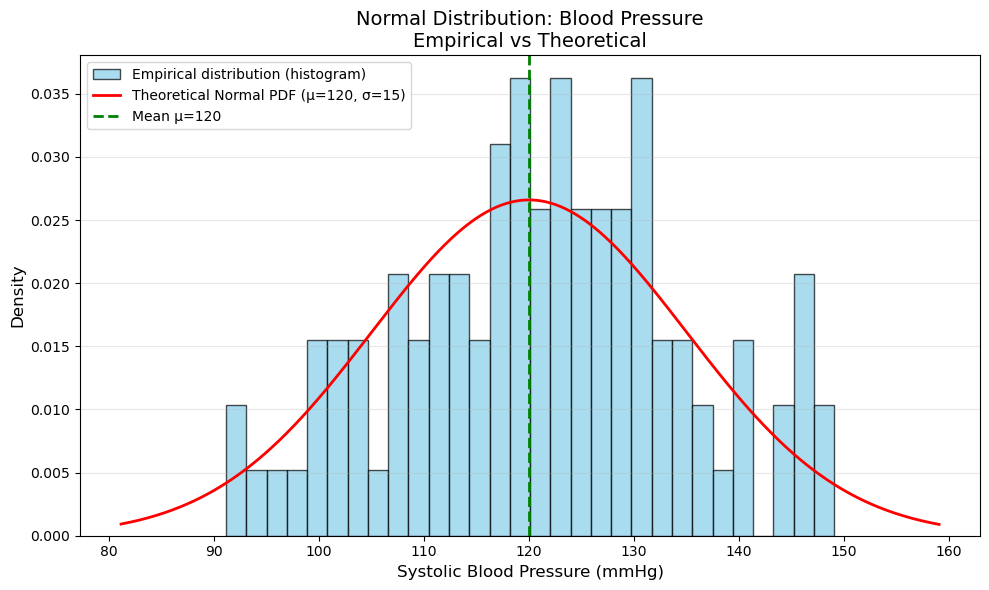

In [10]:
# Create figure
plt.figure(figsize=(10, 6))

# Histogram of empirical data (density=True makes it a probability density)
plt.hist(bp, bins=30, density=True, alpha=0.7, edgecolor="black",
         label="Empirical distribution (histogram)", color='skyblue')

# Theoretical Normal PDF curve
x = np.linspace(bp.min() - 10, bp.max() + 10, 500)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
plt.plot(x, pdf, color="red", linewidth=2,
         label=f"Theoretical Normal PDF (μ={mu}, σ={sigma})")

# Mean reference line
plt.axvline(mu, linestyle='--', color='green', linewidth=2, label=f'Mean μ={mu}')

# Labels and formatting
plt.xlabel("Systolic Blood Pressure (mmHg)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Normal Distribution: Blood Pressure\nEmpirical vs Theoretical", fontsize=14)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**What is PDF?**
- PDF = Probability Density Function (for continuous distributions)
- Unlike PMF (discrete), PDF shows relative likelihood
- Probability = area under the curve, not the height

## Step 2.3: Compare Statistics and Calculate Probabilities

### TASK 4: Calculate Sample Statistics for Normal Data

**Instructions:**
- Calculate the **sample mean** using `np.mean()`
- Calculate the **sample standard deviation** using `np.std()`
- Calculate the **sample variance** using `np.var()`
- Store your results in variables called `sample_mean`, `sample_std`, and `sample_var`

In [11]:
# --- YOUR CODE HERE ---

# Task 4.1: Calculate the sample mean
sample_mean = np.mean(bp)

# Task 4.2: Calculate the sample standard deviation
sample_std = np.std(bp)

# Task 4.3: Calculate the sample variance
sample_var = np.var(bp)

# --- END YOUR CODE ---

# Compare to theoretical values
theoretical_mean = mu
theoretical_std = sigma
theoretical_var = sigma**2

print("STATISTICS COMPARISON")
print(f"\nEmpirical (from {size} simulated patients):")
print(f"Sample mean = {sample_mean:.2f} mmHg")
print(f"Sample std dev = {sample_std:.2f} mmHg")
print(f"Sample variance = {sample_var:.2f}")

print(f"\nTheoretical (Normal with μ={mu}, σ={sigma}):")
print(f"Mean = {theoretical_mean:.2f} mmHg")
print(f"Std dev = {theoretical_std:.2f} mmHg")
print(f"Variance = {theoretical_var:.2f}")

print("\nFor Normal: variance = σ² (NOT equal to mean like Poisson)")
print("With larger N, empirical values approach theoretical values")
print()

STATISTICS COMPARISON

Empirical (from 100 simulated patients):
Sample mean = 121.27 mmHg
Sample std dev = 13.57 mmHg
Sample variance = 184.24

Theoretical (Normal with μ=120, σ=15):
Mean = 120.00 mmHg
Std dev = 15.00 mmHg
Variance = 225.00

For Normal: variance = σ² (NOT equal to mean like Poisson)
With larger N, empirical values approach theoretical values



### TASK 5: Calculate Z-Score

**Instructions:**
- Use the formula: z-score = (value - mean) / standard deviation
- The value is `threshold` (100 mmHg)
- The mean is `mu` (120 mmHg)
- The standard deviation is `sigma` (15 mmHg)
- Store your result in a variable called `z_score`

In [12]:
# --- Calculate P(SBP ≤ 100) ---
threshold = 100  # hypotension threshold
print(f"PROBABILITY: P(SBP ≤ {threshold})")

# Empirical probability
empirical_prob = np.sum(bp <= threshold) / size
print(f"\nEmpirical (from simulation):")
print(f"P(SBP ≤ {threshold}) = {empirical_prob:.4f}")
print(f"... {empirical_prob*100:.1f}% of patients have hypotension")

# Theoretical probability
theoretical_prob = stats.norm.cdf(threshold, loc=mu, scale=sigma)

# --- YOUR CODE HERE ---
# Task: Calculate z-score using the formula
z_score = (threshold - mu) / sigma

# --- END YOUR CODE ---

print(f"\nTheoretical (Normal distribution):")
print(f"P(SBP ≤ {threshold}) = {theoretical_prob:.4f}")
print(f"Z-score = {z_score:.2f} ({abs(z_score):.2f} std devs below mean)")

print(f"\nDifference: {abs(empirical_prob - theoretical_prob):.4f}")
print("Values are fairly close (once again). With larger N, they would get even closer.")

PROBABILITY: P(SBP ≤ 100)

Empirical (from simulation):
P(SBP ≤ 100) = 0.0700
... 7.0% of patients have hypotension

Theoretical (Normal distribution):
P(SBP ≤ 100) = 0.0912
Z-score = -1.33 (1.33 std devs below mean)

Difference: 0.0212
Values are fairly close (once again). With larger N, they would get even closer.


**What is CDF?**
- CDF = Cumulative Distribution Function  
- `stats.norm.cdf(100, loc=120, scale=15)` calculates P(X ≤ 100)
- It gives the area under the Normal curve to the left of 100

**What is Z-score?**
- Z-score = (value - mean) / std dev
- Tells us how many standard deviations away from the mean
- Negative z-score = below the mean

## QUESTION 2

Based on the Normal distribution simulation with μ = 120 mmHg and σ = 15 mmHg:

**a)** Compare the sample mean and sample variance to the theoretical values. Are they close? Why might they differ?

**b)** Using the empirical rule (68-95-99.7 rule):
   - What range should contain approximately 68% of blood pressure readings?
   - What range should contain approximately 95% of blood pressure readings?

**c)** If the standard deviation decreased from σ = 15 to σ = 10 (keeping μ = 120), would P(SBP ≤ 100) increase or decrease? Explain your reasoning.

**YOUR ANSWER:**

a) the sample mean obtained was 121.27 mmHg and for sample variance was 184.24. The theoretical values that are obtained are with μ = 120 and σ = 15 is mean at 120.00 mmHg and variance at 225.00. Comparing the sample mean with theoretical gives 98.95% similiarity whereas with variance it is 81.88% which is pretty close. However since the sample size is at 100 patients, that is why it is different from the theoretical values given. If the sample size is large enough >>100, then it will get closer to the theoretical values.
b) The range that should contain approximately 68% of blood pressure readings is around 105 to 135 mmHg. For the range that should contain approximately 95% of blood pressure readings is around 90 to 150 mmHg.
c) using math: Z = (100-120)/10 = -2.0 for Z-score. For corresponding Z-score of -2.0, the probability is decreased (around 0.0228 compared to 0.0912) as it moves away from 0 at a normal distribution and is less than -1.33. Therefore the P(SBP ≤ 100) would decrease as it is less than -1.33 Z score.

# Reflection Questions

Now that you've worked through simulations of both Poisson and Normal distributions, take a moment to reflect on what you've learned.

**Question 1:** You are designing an health monitoring system that tracks the number of patient falls per week in a hospital ward. Would you use a Poisson distribution or a Normal distribution to model this data? Explain your reasoning, referring to the characteristics of each distribution.

**Question 2:** Explain why it's useful to simulate data and compare empirical distributions to theoretical distributions. What does this teach us about probability models in biomedical engineering? How does sample size affect the comparison?

**YOUR ANSWERS:**

Q.1) For tracking the number of patient falls per week, we should use a Poisson distribution as patient falls are count data which are events that we count as discrete units rather than measure on a continuous scale. Additionally, falls are independent events as one patient falling does not necessarily increase the likelihood of another patient falling. Normal distributions deal with continous data and therefore would not work for such distributions. 

Q.2) The reason why it is usefull to simulate data and compare empirical distributions to theoretical distributions is that it allows individuals to verify that the data-generating process correctly reflects the underlying probability model. In biomedical engineering, these probabilty models allow us to predict the probability of events that can help if certain events were to happen, i.e patient sickness or disease in a city. This can be used to help matigate situations and be aware to change course or find solutions. Sample size affect comparisons as large sample size tend to get closer to theoretical values.

# Submission Instructions

**Due Date:** Friday, January 23, 2026

**How to Submit:**
1. Make sure all code cells have been run and show outputs
2. Make sure all question cells are filled in with your answers
3. Save your notebook as: `Tutorial2_YourName.ipynb` (replace "YourName" with your actual name)
4. Submit your completed notebook to the **Tutorial 2 dropbox on Avenue to Learn**

**Need Help?**
- Jala and Imran will be available during office hours on **Wednesday (today)** and **Thursday**
- Check Avenue to Learn for office hours times and locations
- You can also post questions on the course discussion board